In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    QuantileTransformer,
    StandardScaler,
)

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_CATEGORIZADOS, RANDOM_STATE
from src.graficos import plot_coeficientes, plot_residuos

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_CATEGORIZADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,triglicerides,glicose,target,colesterol_hdl_cat
0,59,2,32.099998,101.0,157,93.199997,38.0,4.8598,87,151,4-5
1,48,1,21.600000,87.0,183,103.199997,70.0,3.8918,69,75,2-3
2,72,2,30.500000,93.0,156,93.599998,41.0,4.6728,85,141,4-5
3,24,1,25.299999,84.0,198,131.399994,40.0,4.8903,89,206,4-5
4,50,1,23.000000,101.0,192,125.400002,52.0,4.2905,80,135,4-5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   idade               442 non-null    int8    
 1   sexo                442 non-null    int8    
 2   imc                 442 non-null    float32 
 3   pressao_media       442 non-null    float32 
 4   colesterol_total    442 non-null    int16   
 5   ldl                 442 non-null    float32 
 6   hdl                 442 non-null    float32 
 7   triglicerides       442 non-null    float32 
 8   glicose             442 non-null    int8    
 9   target              442 non-null    int16   
 10  colesterol_hdl_cat  442 non-null    category
dtypes: category(1), float32(5), int16(2), int8(3)
memory usage: 12.3 KB


In [4]:
colunas_power_transform = ["imc", "ldl", "hdl", "colesterol_total"]

coluna_target = ["target"]

coluna_ordinal_encoder = ["colesterol_hdl_cat"]

coluna_one_hot_encoder = ["sexo"]

colunas_standard_scaler = [
    coluna
    for coluna in df.columns
    if coluna not in colunas_power_transform + coluna_target + coluna_ordinal_encoder + coluna_one_hot_encoder
]

colunas_standard_scaler

['idade', 'pressao_media', 'triglicerides', 'glicose']

In [5]:
categorias_ordinal_encoder = [
    ["2-3", "4-5", "6+"],
]

In [6]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [7]:
preprocessamento = ColumnTransformer(
    [
        ("power_transform", PowerTransformer(method="box-cox"), colunas_power_transform),
        ("standard_scaler", StandardScaler(), colunas_standard_scaler),
        ("ordinal_encoder", OrdinalEncoder(categories=categorias_ordinal_encoder), coluna_ordinal_encoder),
        ("one_hot_encoder", OneHotEncoder(drop="if_binary"), coluna_one_hot_encoder),
    ]
)

In [8]:
pipeline = Pipeline([
    ("preprocessor", preprocessamento),
    ("reg", LinearRegression())
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('power_transform',
                                                  PowerTransformer(method='box-cox'),
                                                  ['imc', 'ldl', 'hdl',
                                                   'colesterol_total']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['idade', 'pressao_media',
                                                   'triglicerides',
                                                   'glicose']),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['2-3',
                                                                              '4-5',
                                                                              '6+']]),
                                                  ['colesterol_hdl_cat']),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['sexo'])])),
                ('reg', LinearRegression())])

https://scikit-learn.org/stable/auto_examples/compose/plot_transformed_target.html

https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html

In [9]:
regressor = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=QuantileTransformer(n_quantiles=20, output_distribution="normal")
)

regressor

TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('power_transform',
                                                                                       PowerTransformer(method='box-cox'),
                                                                                       ['imc',
                                                                                        'ldl',
                                                                                        'hdl',
                                                                                        'colesterol_total']),
                                                                                      ('standard_scaler',
                                                                                       StandardScaler(),
                                                                                       ['idade',
                                                                                        'pressao_media',
                                                                                        'triglicerides',
                                                                                        'glicose']),
                                                                                      ('ordinal_encoder',
                                                                                       OrdinalEncoder(categories=[['2-3',
                                                                                                                   '4-5',
                                                                                                                   '6+']]),
                                                                                       ['colesterol_hdl_cat']),
                                                                                      ('one_hot_encoder',
                                                                                       OneHotEncoder(drop='if_binary'),
                                                                                       ['sexo'])])),
                                                     ('reg',
                                                      LinearRegression())]),
                           transformer=QuantileTransformer(n_quantiles=20,
                                                           output_distribution='normal'))

In [10]:
regressor.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('power_transform',
                                                                                       PowerTransformer(method='box-cox'),
                                                                                       ['imc',
                                                                                        'ldl',
                                                                                        'hdl',
                                                                                        'colesterol_total']),
                                                                                      ('standard_scaler',
                                                                                       StandardScaler(),
                                                                                       ['idade',
                                                                                        'pressao_media',
                                                                                        'triglicerides',
                                                                                        'glicose']),
                                                                                      ('ordinal_encoder',
                                                                                       OrdinalEncoder(categories=[['2-3',
                                                                                                                   '4-5',
                                                                                                                   '6+']]),
                                                                                       ['colesterol_hdl_cat']),
                                                                                      ('one_hot_encoder',
                                                                                       OneHotEncoder(drop='if_binary'),
                                                                                       ['sexo'])])),
                                                     ('reg',
                                                      LinearRegression())]),
                           transformer=QuantileTransformer(n_quantiles=20,
                                                           output_distribution='normal'))

In [11]:
regressor.regressor_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('power_transform',
                                                  PowerTransformer(method='box-cox'),
                                                  ['imc', 'ldl', 'hdl',
                                                   'colesterol_total']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['idade', 'pressao_media',
                                                   'triglicerides',
                                                   'glicose']),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['2-3',
                                                                              '4-5',
                                                                              '6+']]),
                                                  ['colesterol_hdl_cat']),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['sexo'])])),
                ('reg', LinearRegression())])

In [12]:
regressor.transformer_

QuantileTransformer(n_quantiles=20, output_distribution='normal')

In [13]:
regressor.regressor_.named_steps

{'preprocessor': ColumnTransformer(transformers=[('power_transform',
                                  PowerTransformer(method='box-cox'),
                                  ['imc', 'ldl', 'hdl', 'colesterol_total']),
                                 ('standard_scaler', StandardScaler(),
                                  ['idade', 'pressao_media', 'triglicerides',
                                   'glicose']),
                                 ('ordinal_encoder',
                                  OrdinalEncoder(categories=[['2-3', '4-5',
                                                              '6+']]),
                                  ['colesterol_hdl_cat']),
                                 ('one_hot_encoder',
                                  OneHotEncoder(drop='if_binary'), ['sexo'])]),
 'reg': LinearRegression()}

In [14]:
regressor.regressor_["reg"].coef_

array([ 0.31483251,  0.31892941,  0.04103149, -0.54429855,  0.02065791,
        0.16631542,  0.45027718,  0.03326155,  0.18542347, -0.31685862])

In [15]:
regressor.regressor_["reg"].intercept_

np.float64(0.016668230568278607)

In [16]:
regressor.regressor_["preprocessor"].feature_names_in_

array(['idade', 'sexo', 'imc', 'pressao_media', 'colesterol_total', 'ldl',
       'hdl', 'triglicerides', 'glicose', 'colesterol_hdl_cat'],
      dtype=object)

In [17]:
regressor.regressor_["preprocessor"].get_feature_names_out()

array(['power_transform__imc', 'power_transform__ldl',
       'power_transform__hdl', 'power_transform__colesterol_total',
       'standard_scaler__idade', 'standard_scaler__pressao_media',
       'standard_scaler__triglicerides', 'standard_scaler__glicose',
       'ordinal_encoder__colesterol_hdl_cat', 'one_hot_encoder__sexo_2'],
      dtype=object)

In [18]:
coefs = dataframe_coeficientes(
    regressor.regressor_["reg"].coef_,
    regressor.regressor_["preprocessor"].get_feature_names_out()
)
coefs

,coeficiente
power_transform__colesterol_total,-0.544299
one_hot_encoder__sexo_2,-0.316859
standard_scaler__idade,0.020658
standard_scaler__glicose,0.033262
power_transform__hdl,0.041031
standard_scaler__pressao_media,0.166315
ordinal_encoder__colesterol_hdl_cat,0.185423
power_transform__imc,0.314833
power_transform__ldl,0.318929
standard_scaler__triglicerides,0.450277


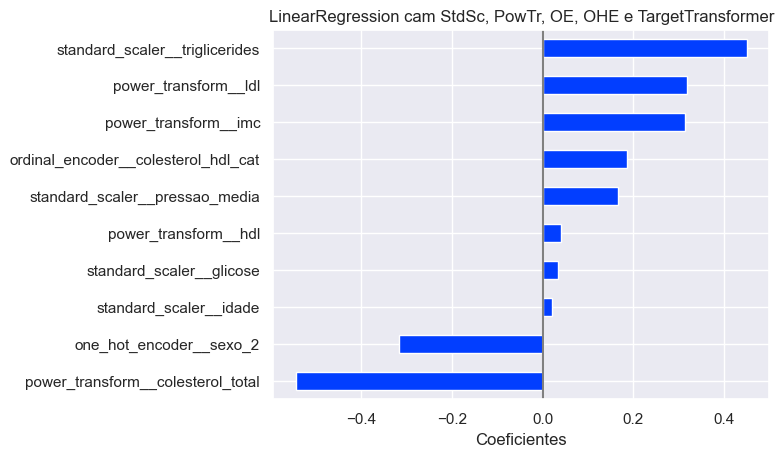

In [19]:
plot_coeficientes(coefs, titulo="LinearRegression cam StdSc, PowTr, OE, OHE e TargetTransformer")

In [24]:
df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,triglicerides,glicose,target,colesterol_hdl_cat
0,59,2,32.099998,101.0,157,93.199997,38.0,4.8598,87,151,4-5
1,48,1,21.600000,87.0,183,103.199997,70.0,3.8918,69,75,2-3
2,72,2,30.500000,93.0,156,93.599998,41.0,4.6728,85,141,4-5
3,24,1,25.299999,84.0,198,131.399994,40.0,4.8903,89,206,4-5
4,50,1,23.000000,101.0,192,125.400002,52.0,4.2905,80,135,4-5


In [23]:
y

0      151
1       75
2      141
3      206
4      135
      ... 
437    178
438    104
439    132
440    220
441     57
Name: target, Length: 442, dtype: int16

In [26]:
y.shape

(442,)

In [27]:
y.values

array([151,  75, 141, 206, 135,  97, 138,  63, 110, 310, 101,  69, 179,
       185, 118, 171, 166, 144,  97, 168,  68,  49,  68, 245, 184, 202,
       137,  85, 131, 283, 129,  59, 341,  87,  65, 102, 265, 276, 252,
        90, 100,  55,  61,  92, 259,  53, 190, 142,  75, 142, 155, 225,
        59, 104, 182, 128,  52,  37, 170, 170,  61, 144,  52, 128,  71,
       163, 150,  97, 160, 178,  48, 270, 202, 111,  85,  42, 170, 200,
       252, 113, 143,  51,  52, 210,  65, 141,  55, 134,  42, 111,  98,
       164,  48,  96,  90, 162, 150, 279,  92,  83, 128, 102, 302, 198,
        95,  53, 134, 144, 232,  81, 104,  59, 246, 297, 258, 229, 275,
       281, 179, 200, 200, 173, 180,  84, 121, 161,  99, 109, 115, 268,
       274, 158, 107,  83, 103, 272,  85, 280, 336, 281, 118, 317, 235,
        60, 174, 259, 178, 128,  96, 126, 288,  88, 292,  71, 197, 186,
        25,  84,  96, 195,  53, 217, 172, 131, 214,  59,  70, 220, 268,
       152,  47,  74, 295, 101, 151, 127, 237, 225,  81, 151, 10

In [29]:
# como é um array do numpy, podemos usar um reshape para adicionar mais uma dimenssão
# -1 (dimenssão que já existe)    1 (nova dimenssão)

y.values.reshape(-1,1)[:10]

array([[151],
       [ 75],
       [141],
       [206],
       [135],
       [ 97],
       [138],
       [ 63],
       [110],
       [310]], dtype=int16)

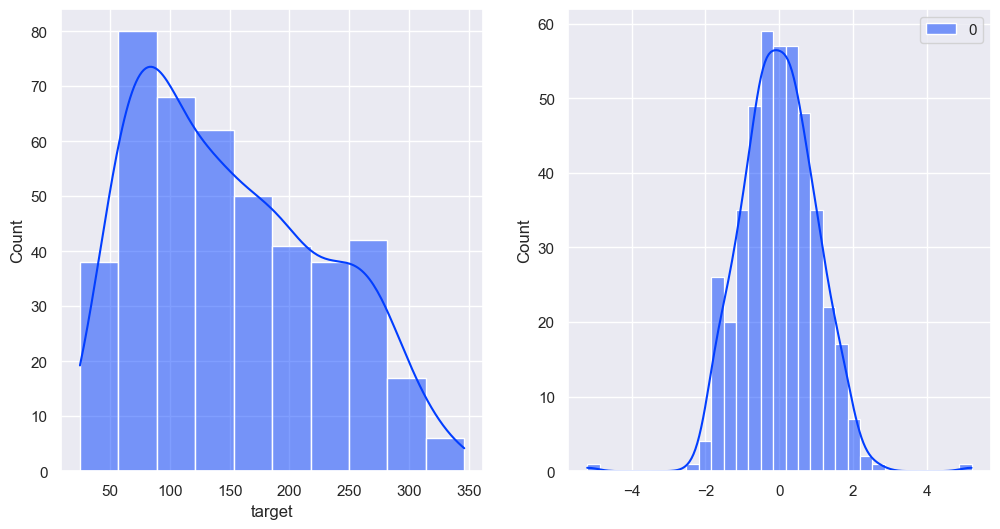

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(y, ax=axs[0], kde=True)

y_trandformado = regressor.transformer_.transform(y.values.reshape(-1,1))

sns.histplot(y_trandformado, ax=axs[1], kde=True)

plt.show()

In [35]:
y.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [34]:
# Fazendo a inversa da transformação para obter uma faixa de valores dentro daquilo que esperamos.

regressor.transformer_.inverse_transform([[-5]])

array([[25.00014161]])

In [36]:
regressor.transformer_.inverse_transform([[0]])

array([[141.13157895]])

In [37]:
regressor.transformer_.inverse_transform([[5]])

array([[345.99965688]])

In [39]:
y_pred = regressor.predict(X_test)

y_pred

array([137.11991947, 175.92264036, 137.49765055, 280.68704836,
       103.83682454,  87.25063309, 244.36503928, 186.25243243,
        75.79334239,  97.16696807,  78.68336683, 172.69388048,
        61.34382122, 205.92380907,  81.15117655, 121.08312572,
       225.20775497, 258.13593682, 216.86120594, 213.82299768,
       230.08062683,  82.54607287,  63.94203883, 196.0954359 ,
       142.07786762, 155.93296633, 189.81093448, 174.64923306,
        55.79751197,  98.09817393, 166.3369498 ,  80.00446181,
       134.36283954, 182.29634378, 173.7262751 , 192.72983112,
       118.7621617 , 104.80516369, 134.39309921,  59.1194212 ,
        62.54076868,  83.83750368, 170.98971854, 147.4774986 ,
       173.09893223,  60.43651254,  71.81792937,  87.7640689 ,
        55.37329082, 172.13837901, 151.83977999,  63.06400536,
        91.71997809,  89.28816896, 159.90901813, 138.20747599,
        84.93397442, 224.99946513, 104.79150373,  66.92034788,
       200.1032732 , 227.29915516, 124.04737524,  80.23

In [40]:
mean_absolute_error(y_test, y_pred)

np.float64(42.03726976407878)

In [41]:
mean_squared_error(y_test, y_pred)

np.float64(2908.1009090910125)

In [43]:
root_mean_squared_error(y_test, y_pred)

np.float64(53.926810670491285)

In [44]:
r2_score(y_test, y_pred)

0.45111030277582465

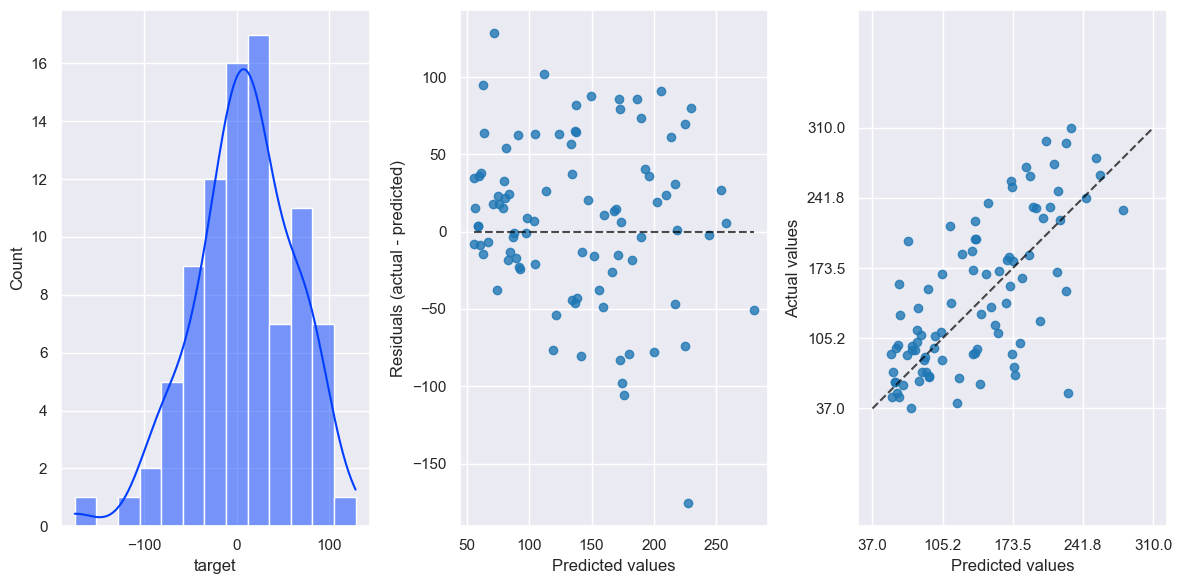

In [45]:
plot_residuos(y_test, y_pred)